In [1]:
pip install pandas numpy scikit-learn matplotlib seaborn


[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report
)


df = pd.read_csv("/Users/thuynguyen/Downloads/heart_disease_health_indicators_BRFSS2015.csv")

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nTarget variable distribution:")
print(df["HeartDiseaseorAttack"].value_counts())
print(df["HeartDiseaseorAttack"].value_counts(normalize=True) * 100)

Dataset shape: (253680, 22)

Columns:
['HeartDiseaseorAttack', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'Diabetes', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']

Missing values:
HeartDiseaseorAttack    0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
Diabetes                0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

Target variable distribution:
HeartDiseaseorAttack
0.0    229787
1.0     23893
Name: c

In [5]:
target = "HeartDiseaseorAttack"

X = df.drop(columns=[target])
y = df[target]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining set size:", X_train.shape)
print("Testing set size:", X_test.shape)


Training set size: (202944, 21)
Testing set size: (50736, 21)


In [9]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ))
    ]),
    
    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        class_weight="balanced",
        random_state=42
    ),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
}

results = []

for name, model in models.items():
    print("\n==============================")
    print(name)
    print("==============================")
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    
    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "AUC-ROC": auc
    })
    
    print(classification_report(y_test, y_pred))
    print("AUC-ROC:", round(auc, 4))


Logistic Regression
              precision    recall  f1-score   support

         0.0       0.97      0.75      0.85     45957
         1.0       0.25      0.80      0.38      4779

    accuracy                           0.75     50736
   macro avg       0.61      0.77      0.61     50736
weighted avg       0.90      0.75      0.80     50736

AUC-ROC: 0.847

Decision Tree
              precision    recall  f1-score   support

         0.0       0.97      0.74      0.84     45957
         1.0       0.23      0.76      0.35      4779

    accuracy                           0.74     50736
   macro avg       0.60      0.75      0.60     50736
weighted avg       0.90      0.74      0.79     50736

AUC-ROC: 0.8212

Random Forest
              precision    recall  f1-score   support

         0.0       0.97      0.74      0.84     45957
         1.0       0.25      0.80      0.37      4779

    accuracy                           0.75     50736
   macro avg       0.61      0.77      0.61   

In [11]:
results_df = pd.DataFrame(results)
print("\nModel Performance Summary:")
print(results_df)

results_df.to_csv("model_performance_results.csv", index=False)


Model Performance Summary:
                 Model  Accuracy  Precision    Recall  F1 Score   AUC-ROC
0  Logistic Regression  0.753430   0.248159  0.797029  0.378478  0.847031
1        Decision Tree  0.738864   0.231179  0.762084  0.354746  0.821183
2        Random Forest  0.749626   0.245045  0.796819  0.374822  0.845954


<Figure size 1000x600 with 0 Axes>

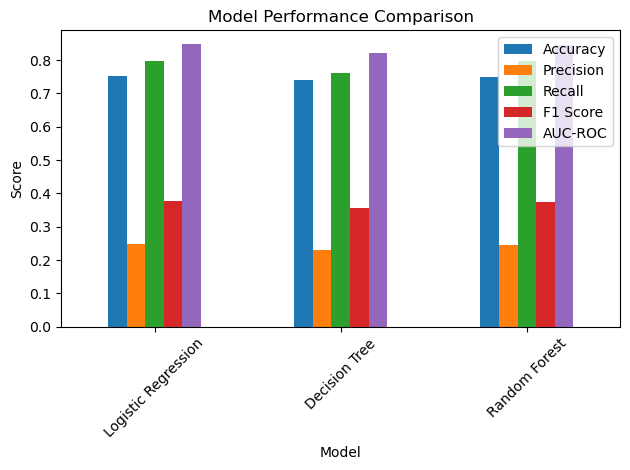

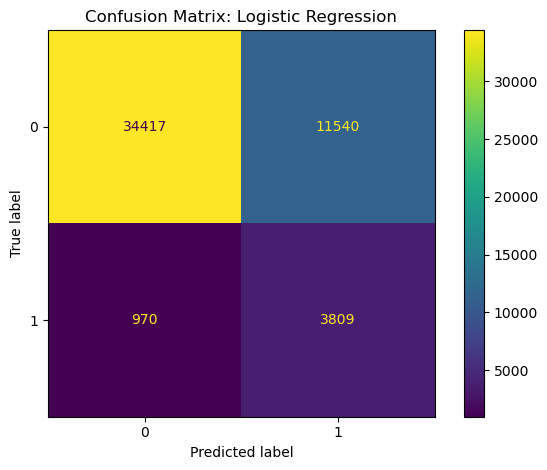

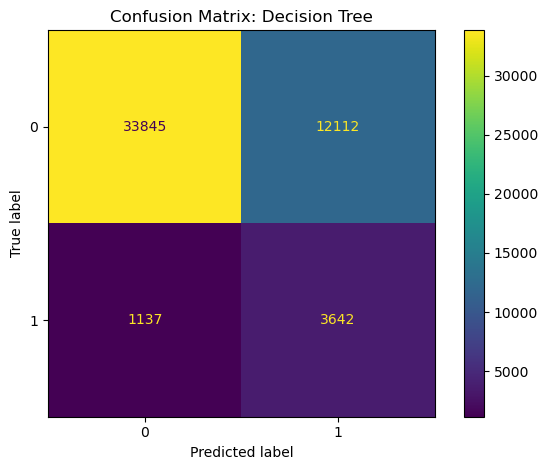

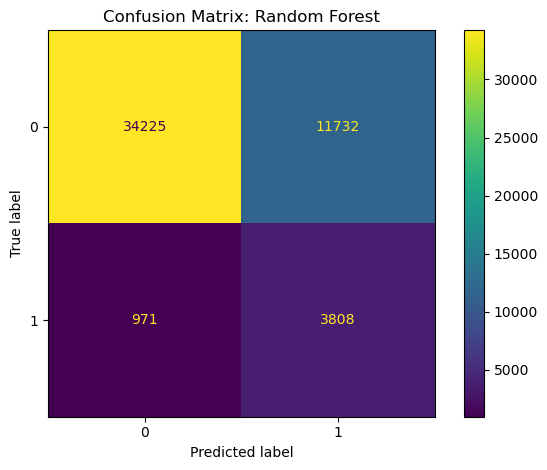

In [13]:
plt.figure(figsize=(10, 6))
results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score", "AUC-ROC"]].plot(kind="bar")
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("model_performance_comparison.png", dpi=300)
plt.show()

for name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Confusion Matrix: {name}")
    plt.tight_layout()
    plt.savefig(f"confusion_matrix_{name.replace(' ', '_')}.png", dpi=300)
    plt.show()

<Figure size 800x600 with 0 Axes>

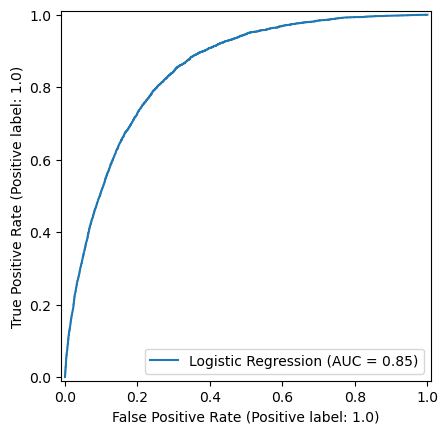

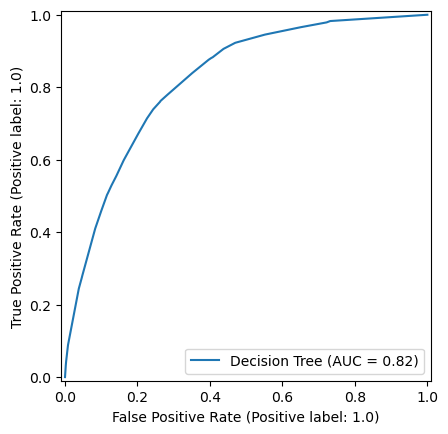

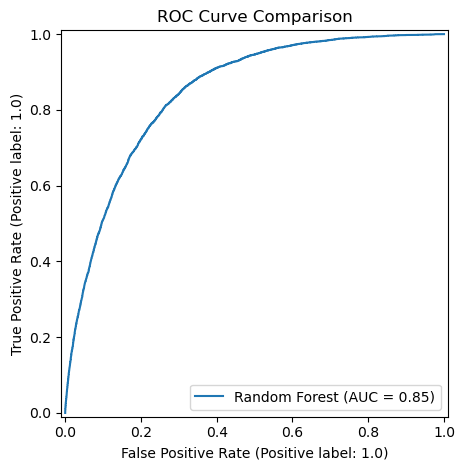

In [15]:
plt.figure(figsize=(8, 6))

for name, model in models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, name=name)

plt.title("ROC Curve Comparison")
plt.tight_layout()
plt.savefig("roc_curve_comparison.png", dpi=300)
plt.show()

In [17]:
rf_model = models["Random Forest"]
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nRandom Forest Feature Importance:")
print(feature_importance)


Random Forest Feature Importance:
              Feature  Importance
18                Age    0.213064
13            GenHlth    0.180333
0              HighBP    0.149050
1            HighChol    0.091006
16           DiffWalk    0.073117
5              Stroke    0.050064
15           PhysHlth    0.045544
17                Sex    0.044724
6            Diabetes    0.039266
20             Income    0.029595
4              Smoker    0.024804
3                 BMI    0.017962
19          Education    0.010686
14           MentHlth    0.010480
7        PhysActivity    0.003898
2           CholCheck    0.003032
8              Fruits    0.002858
12        NoDocbcCost    0.002856
10  HvyAlcoholConsump    0.002608
9             Veggies    0.002600
11      AnyHealthcare    0.002453


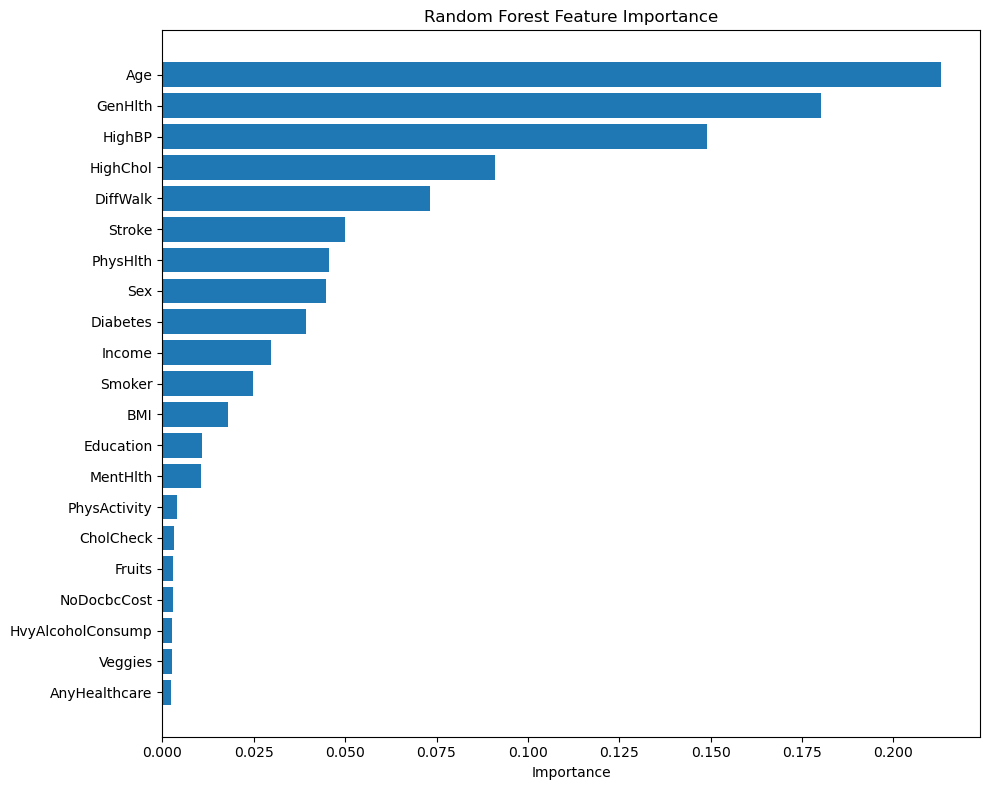


Logistic Regression Odds Ratios:
              Feature  Coefficient  Odds Ratio
18                Age     0.846608    2.331725
13            GenHlth     0.527404    1.694527
17                Sex     0.408648    1.504782
1            HighChol     0.315863    1.371442
0              HighBP     0.276679    1.318743
5              Stroke     0.222490    1.249184
4              Smoker     0.190853    1.210282
16           DiffWalk     0.119921    1.127408
6            Diabetes     0.108077    1.114133
2           CholCheck     0.097060    1.101927
12        NoDocbcCost     0.075062    1.077951
14           MentHlth     0.041539    1.042414
15           PhysHlth     0.027069    1.027439
7        PhysActivity     0.019143    1.019328
9             Veggies     0.017120    1.017268
3                 BMI     0.011795    1.011865
19          Education     0.003052    1.003057
8              Fruits     0.002881    1.002885
11      AnyHealthcare    -0.018791    0.981385
10  HvyAlcoholConsump    -

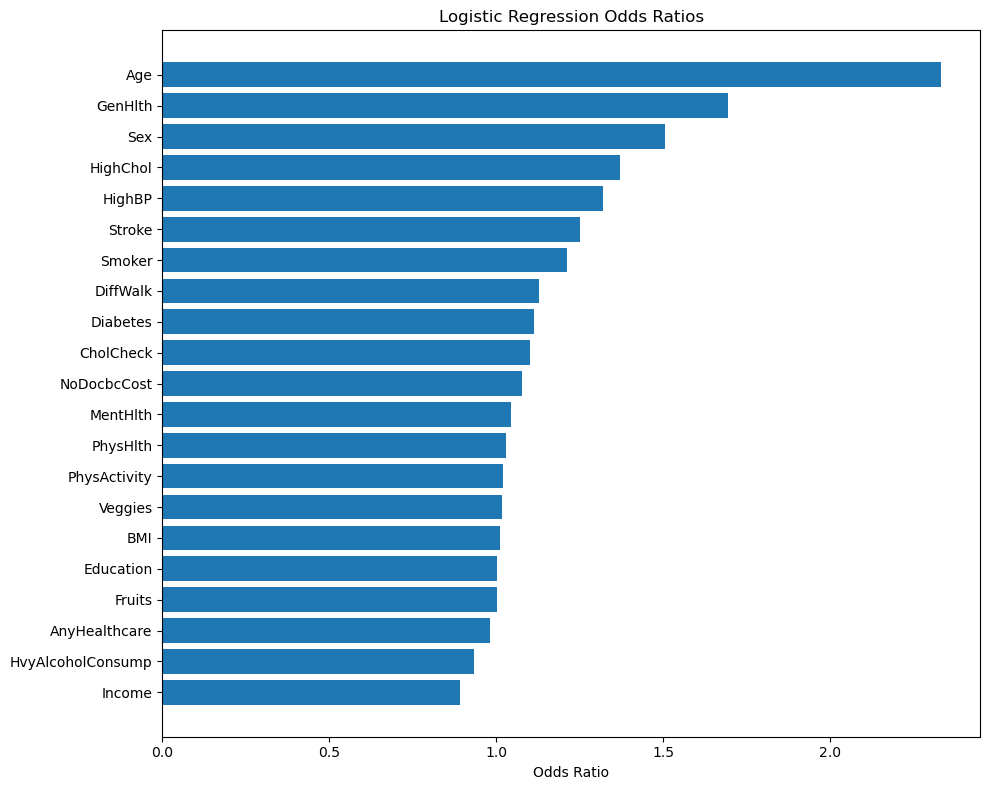

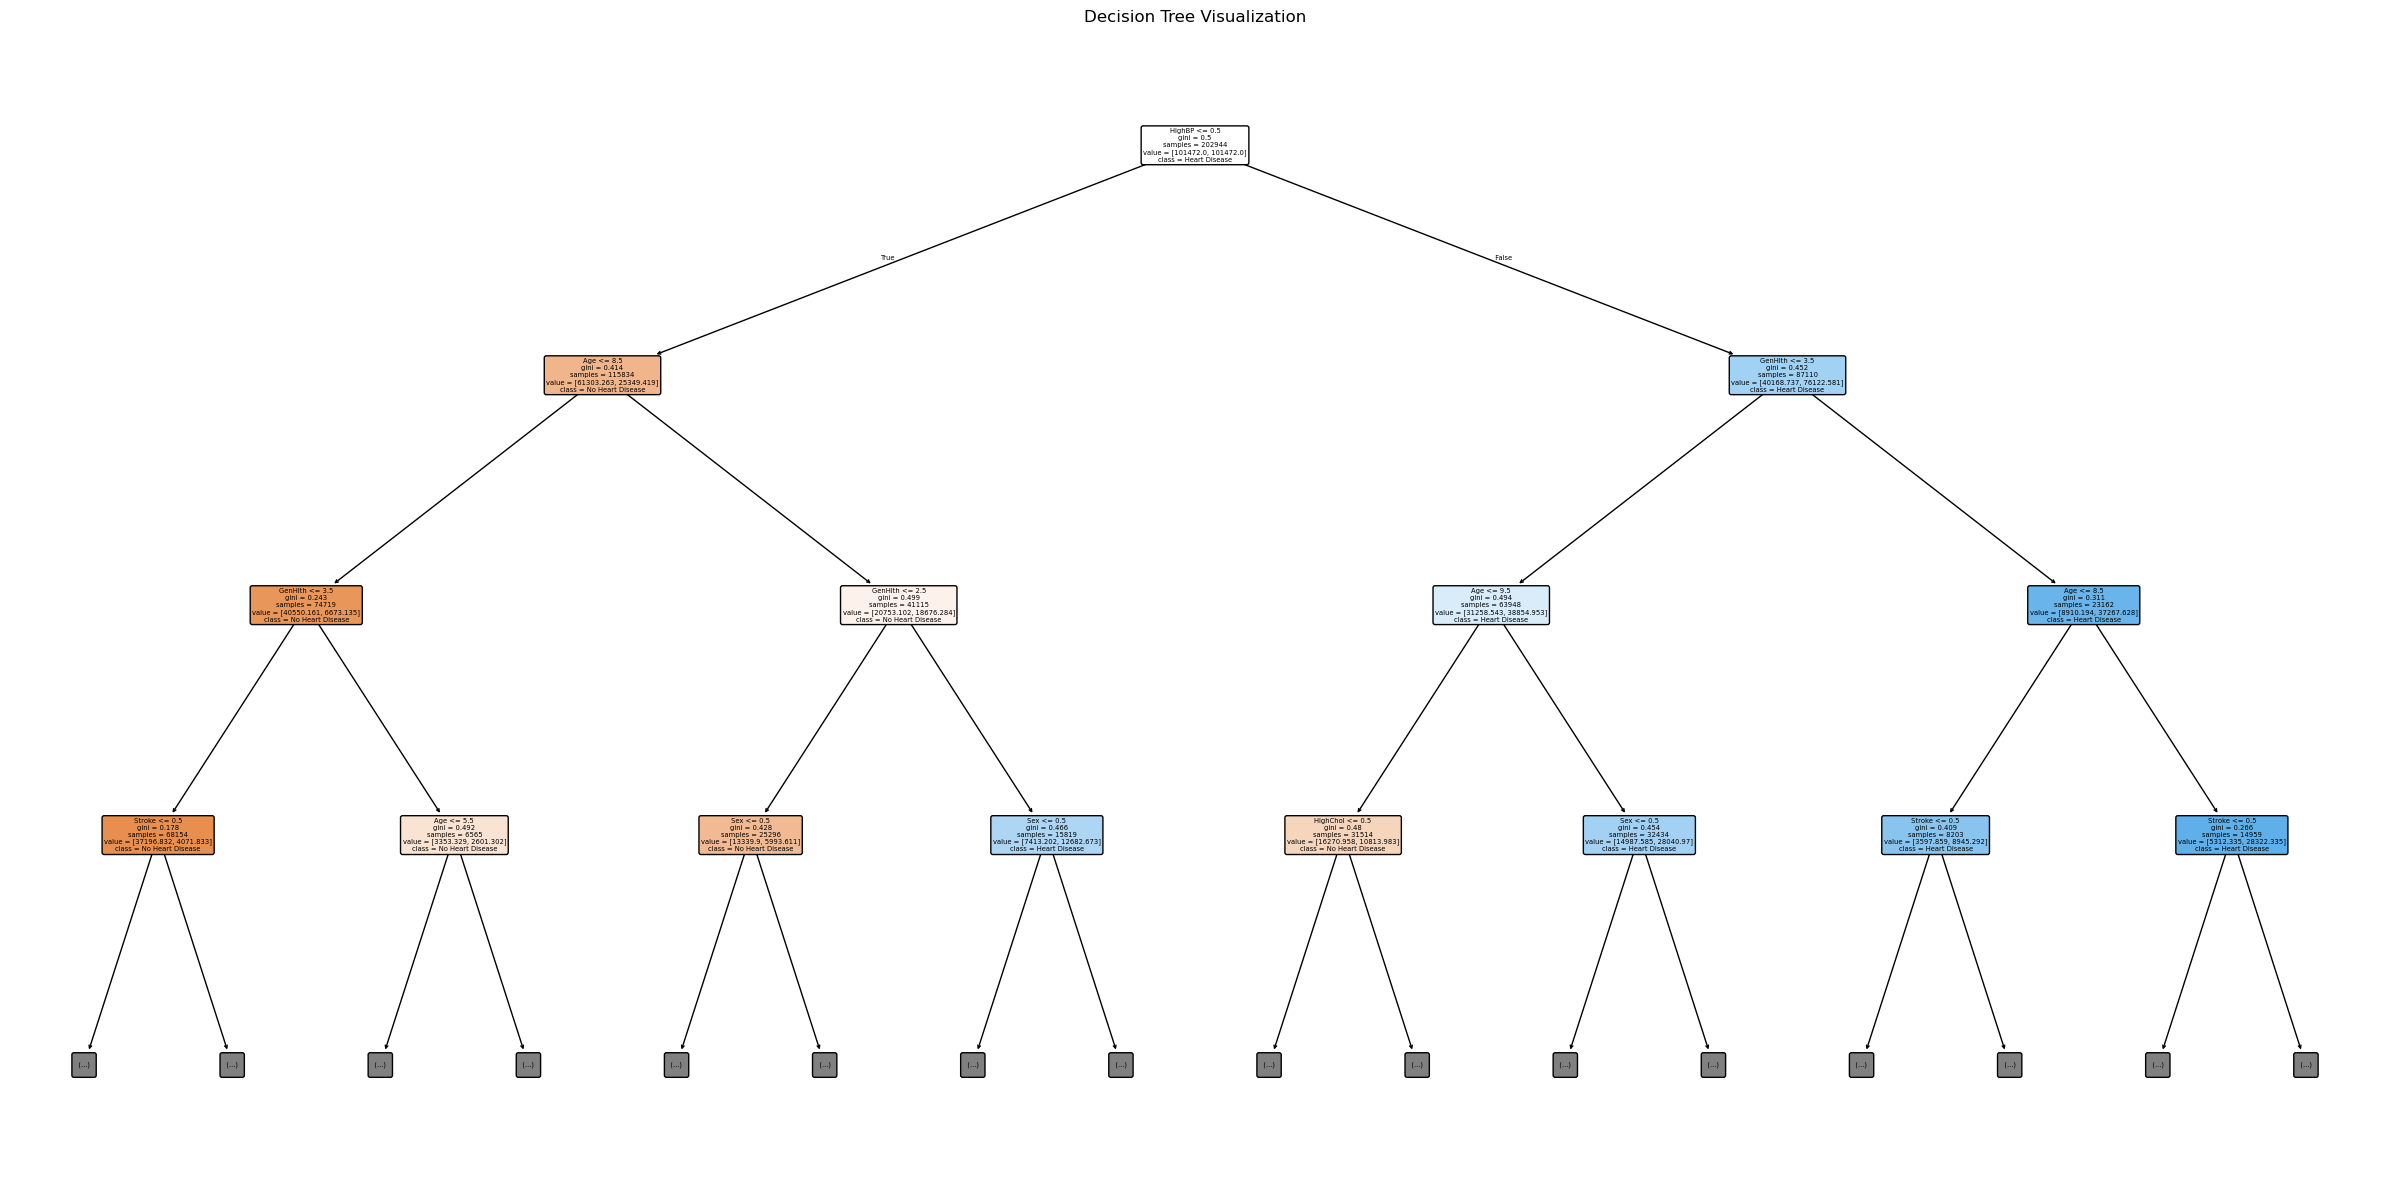

In [19]:
feature_importance.to_csv("random_forest_feature_importance.csv", index=False)

plt.figure(figsize=(10, 8))
plt.barh(feature_importance["Feature"], feature_importance["Importance"])
plt.gca().invert_yaxis()
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("random_forest_feature_importance.png", dpi=300)
plt.show()

log_model = models["Logistic Regression"].named_steps["model"]

odds_ratios = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_model.coef_[0],
    "Odds Ratio": np.exp(log_model.coef_[0])
}).sort_values(by="Odds Ratio", ascending=False)

print("\nLogistic Regression Odds Ratios:")
print(odds_ratios)

odds_ratios.to_csv("logistic_regression_odds_ratios.csv", index=False)

plt.figure(figsize=(10, 8))
plt.barh(odds_ratios["Feature"], odds_ratios["Odds Ratio"])
plt.gca().invert_yaxis()
plt.title("Logistic Regression Odds Ratios")
plt.xlabel("Odds Ratio")
plt.tight_layout()
plt.savefig("logistic_regression_odds_ratios.png", dpi=300)
plt.show()

tree_model = models["Decision Tree"]

plt.figure(figsize=(24, 12))
plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=["No Heart Disease", "Heart Disease"],
    filled=True,
    rounded=True,
    max_depth=3
)
plt.title("Decision Tree Visualization")
plt.tight_layout()
plt.savefig("decision_tree_visualization.png", dpi=300)
plt.show()